In [1]:
import pandas as pd
import numpy as np

In [2]:
global_df = pd.read_csv(
    "../data/processed/global_watch_market.csv"
)

ebay_df = pd.read_csv(
    "../data/processed/ebay_market_sample.csv"
)

trends_df = pd.read_csv(
    "../data/processed/google_trends_brand_attention.csv"
)

rolex_hist_df = pd.read_csv(
    "../data/processed/rolex_historical_market.csv"
)

rolex_live_df = pd.read_csv(
    "../data/processed/rolex_live_market.csv"
)

/var/folders/qm/8k39nttx5q3509dgt0k121340000gn/T/ipykernel_27040/1859131569.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  global_df = pd.read_csv(


In [3]:
global_df.head()

,unnamed: 0,name,price,brand,model,ref,mvmt,casem,bracem,yop,cond,sex,size,condition,reference
0,0,Audemars Piguet Royal Oak Offshore Chronograph...,43500.0,Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,NaN,NaN,NaN,2019,Unworn,Men's watch/Unisex,42 mm,NaN,26237ST.OO.1000ST.01
1,1,Audemars Piguet Royal Oak Selfwinding\n39mm Bl...,71500.0,Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,NaN,NaN,NaN,2012,Very good,Men's watch/Unisex,39 mm,NaN,15300ST.OO.1220ST.02
2,2,Audemars Piguet Royal Oak Chronograph\nBlue Di...,79191.0,Audemars Piguet,Royal Oak Chronograph,26331ST,Automatic,Steel,Steel,Unknown,Unworn,NaN,41 mm,NaN,26331ST
3,3,Audemars Piguet Royal Oak Chronograph\nSelfwin...,108000.0,Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,Automatic,Steel,Steel,2022 (Approximation),New,Men's watch/Unisex,38 mm,NaN,26715ST.OO.1356ST.01
4,4,Audemars Piguet Royal Oak Offshore Chronograph...,27500.0,Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,Automatic,Steel,Steel,Unknown,Very good,Men's watch/Unisex,42 x 54 mm,NaN,26170ST.OO.1000ST.01


In [4]:
global_df.columns


Index(['unnamed: 0', 'name', 'price', 'brand', 'model', 'ref', 'mvmt', 'casem',
       'bracem', 'yop', 'cond', 'sex', 'size', 'condition', 'reference'],
      dtype='object')

In [5]:
ebay_df.columns

Index(['source', 'query', 'title', 'price', 'currency', 'condition',
       'item_url', 'brand', 'collection', 'reference', 'year',
       'market_segment'],
      dtype='object')

In [6]:
trends_df.columns

Index(['brand', 'market_segment', 'trend_group', 'trend_score', 'anchor_brand',
       'anchor_score', 'relative_attention_score'],
      dtype='object')

In [7]:
market_df = global_df.copy()

In [8]:
market_df = market_df.rename(
    columns={
        "model": "collection",
        "mvmt": "movement",
        "casem": "case_material",
        "bracem": "bracelet_material",
        "yop": "year",
        "cond": "condition_raw"
    }
)

In [9]:
market_df = market_df[
    [
        "brand",
        "collection",
        "reference",
        "price",
        "movement",
        "case_material",
        "bracelet_material",
        "year",
        "condition",
        "size"
    ]
].copy()

In [10]:
market_df.head()

,brand,collection,reference,price,movement,case_material,bracelet_material,year,condition,size
0,Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,43500.0,NaN,NaN,NaN,2019,NaN,42 mm
1,Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,71500.0,NaN,NaN,NaN,2012,NaN,39 mm
2,Audemars Piguet,Royal Oak Chronograph,26331ST,79191.0,Automatic,Steel,Steel,Unknown,NaN,41 mm
3,Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,108000.0,Automatic,Steel,Steel,2022 (Approximation),NaN,38 mm
4,Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,27500.0,Automatic,Steel,Steel,Unknown,NaN,42 x 54 mm


In [11]:
market_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284491 entries, 0 to 284490
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   brand              284360 non-null  object 
 1   collection         254025 non-null  object 
 2   reference          241339 non-null  object 
 3   price              269826 non-null  float64
 4   movement           87806 non-null   object 
 5   case_material      120220 non-null  object 
 6   bracelet_material  109595 non-null  object 
 7   year               284357 non-null  object 
 8   condition          71569 non-null   object 
 9   size               260894 non-null  object 
dtypes: float64(1), object(9)
memory usage: 21.7+ MB


In [12]:
segment_map = {
    "TAG Heuer": "Accessible luxury",
    "Longines": "Accessible luxury",

    "Omega": "Broad premium",
    "Cartier": "Broad premium",

    "Rolex": "High prestige",

    "Patek Philippe": "Collector prestige",
    "Audemars Piguet": "Collector prestige",

    "Richard Mille": "Ultra prestige niche"
}

In [13]:
market_df["market_segment"] = (
    market_df["brand"]
    .map(segment_map)
)

In [14]:
trends_small = trends_df[
    [
        "brand",
        "relative_attention_score"
    ]
].copy()

market_df = market_df.merge(
    trends_small,
    on="brand",
    how="left"
)

market_df.head()

,brand,collection,reference,price,movement,case_material,bracelet_material,year,condition,size,market_segment,relative_attention_score
0,Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,43500.0,NaN,NaN,NaN,2019,NaN,42 mm,Collector prestige,0.085438
1,Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,71500.0,NaN,NaN,NaN,2012,NaN,39 mm,Collector prestige,0.085438
2,Audemars Piguet,Royal Oak Chronograph,26331ST,79191.0,Automatic,Steel,Steel,Unknown,NaN,41 mm,Collector prestige,0.085438
3,Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,108000.0,Automatic,Steel,Steel,2022 (Approximation),NaN,38 mm,Collector prestige,0.085438
4,Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,27500.0,Automatic,Steel,Steel,Unknown,NaN,42 x 54 mm,Collector prestige,0.085438


In [15]:
market_df["market_segment"].value_counts(dropna=False)

market_segment
NaN                     101014
High prestige            72484
Broad premium            56238
Accessible luxury        28129
Collector prestige       25384
Ultra prestige niche      1242
Name: count, dtype: int64

In [16]:
market_df[
    ["brand", "market_segment", "relative_attention_score"]
].drop_duplicates().sort_values("relative_attention_score", ascending=False)

,brand,market_segment,relative_attention_score
92027,Omega,Broad premium,1.437219
151521,Rolex,High prestige,1.000000
2901,Cartier,Broad premium,0.629540
139102,Patek Philippe,Collector prestige,0.115531
249560,TAG Heuer,Accessible luxury,0.113026
76752,Longines,Accessible luxury,0.104848
0,Audemars Piguet,Collector prestige,0.085438
24919,Richard Mille,Ultra prestige niche,0.058995
2902,Tudor,NaN,NaN
11059,NaN,NaN,NaN


In [17]:
focus_brands = list(segment_map.keys())

market_focus_df = market_df[
    market_df["brand"].isin(focus_brands)
].copy()

market_focus_df["market_segment"].value_counts(dropna=False)

market_segment
High prestige           72484
Broad premium           56238
Accessible luxury       28129
Collector prestige      25384
Ultra prestige niche     1242
Name: count, dtype: int64

In [18]:
market_focus_df[
    ["brand", "market_segment", "relative_attention_score"]
].drop_duplicates().sort_values(
    "relative_attention_score",
    ascending=False
)

,brand,market_segment,relative_attention_score
92027,Omega,Broad premium,1.437219
151521,Rolex,High prestige,1.000000
2901,Cartier,Broad premium,0.629540
139102,Patek Philippe,Collector prestige,0.115531
249560,TAG Heuer,Accessible luxury,0.113026
76752,Longines,Accessible luxury,0.104848
0,Audemars Piguet,Collector prestige,0.085438
24919,Richard Mille,Ultra prestige niche,0.058995


In [19]:
market_focus_df.to_csv(
    "../data/processed/final_market_structure.csv",
    index=False
)

The analysis focuses on 8 representative luxury watch brands selected to cover the main market segments.

Segment vs Attention
Is luxury watch market attention increasingly concentrated around a limited set of high-visibility brands?
--- prestige ≠ visibility

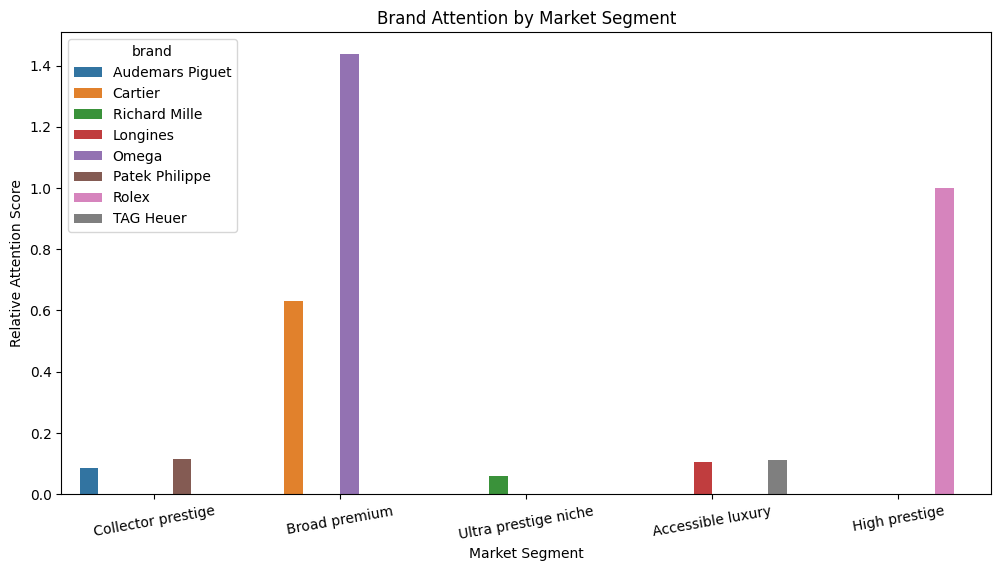

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

attention_df = (
    market_focus_df[
        [
            "brand",
            "market_segment",
            "relative_attention_score"
        ]
    ]
    .drop_duplicates()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=attention_df,
    x="market_segment",
    y="relative_attention_score",
    hue="brand"
)

plt.title("Brand Attention by Market Segment")
plt.ylabel("Relative Attention Score")
plt.xlabel("Market Segment")

plt.xticks(rotation=10)

plt.show()

Attention vs Average Price (market desirability mapping)
Does social attention correlate with luxury pricing?

In [21]:
brand_summary = (
    market_focus_df
    .groupby("brand")
    .agg({
        "price":"mean",
        "relative_attention_score":"mean"
    })
    .reset_index()
)

brand_summary

,brand,price,relative_attention_score
0,Audemars Piguet,73932.483066,0.085438
1,Cartier,8919.843106,0.629540
2,Longines,2347.270951,0.104848
3,Omega,6390.521036,1.437219
4,Patek Philippe,102007.831940,0.115531
5,Richard Mille,370190.514667,0.058995
6,Rolex,21854.864022,1.000000
7,TAG Heuer,3205.537030,0.113026


In [22]:
listing_counts = (
    market_focus_df
    .groupby("brand")
    .size()
    .reset_index(name="listing_count")
)

brand_summary = brand_summary.merge(
    listing_counts,
    on="brand"
)

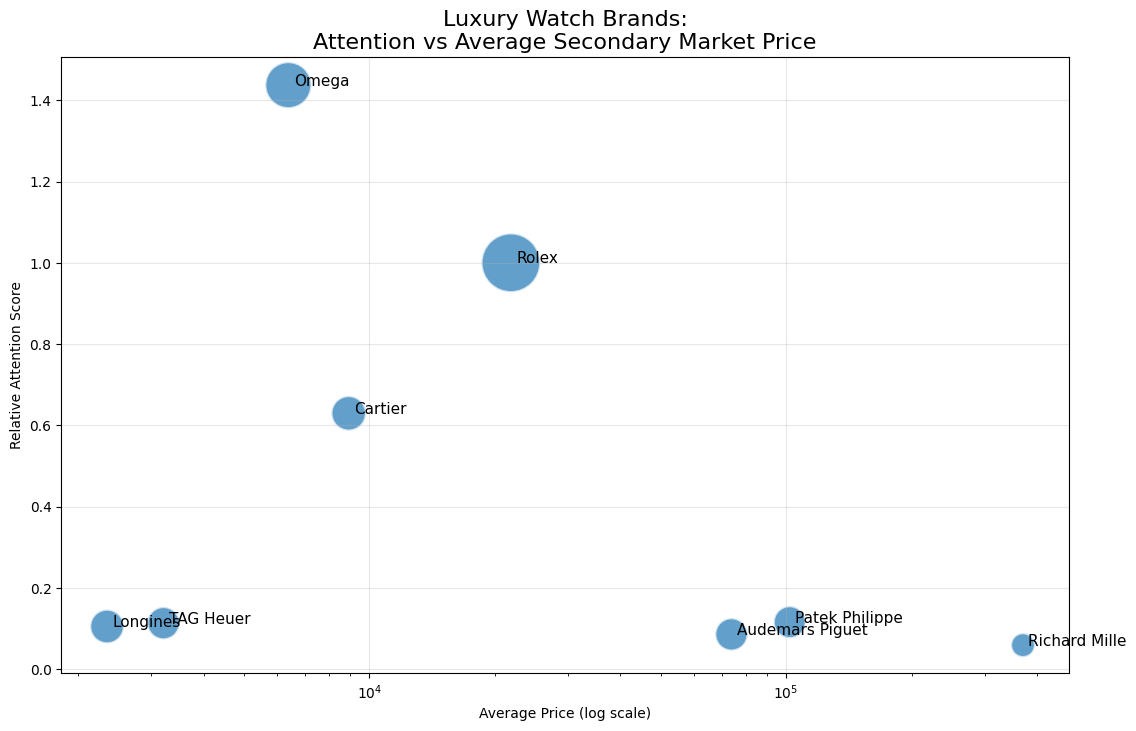

In [27]:
plt.figure(figsize=(13,8))

sns.scatterplot(
    data=brand_summary,
    x="price",
    y="relative_attention_score",
    size="listing_count",
    sizes=(300,1800),
    alpha=0.7,
    legend=False
)

for _, row in brand_summary.iterrows():

    plt.text(
        row["price"] * 1.03,
        row["relative_attention_score"],
        row["brand"],
        fontsize=11
    )

plt.xscale("log")

plt.title(
    "Luxury Watch Brands:\nAttention vs Average Secondary Market Price",
    fontsize=16
)

plt.xlabel("Average Price (log scale)")
plt.ylabel("Relative Attention Score")

plt.grid(alpha=0.3)

plt.show()

Segment concentration
Which luxury segments dominate the secondary market?

In [24]:
segment_counts = (
    market_focus_df["market_segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = [
    "market_segment",
    "listing_count"
]

segment_counts

,market_segment,listing_count
0,High prestige,72484
1,Broad premium,56238
2,Accessible luxury,28129
3,Collector prestige,25384
4,Ultra prestige niche,1242


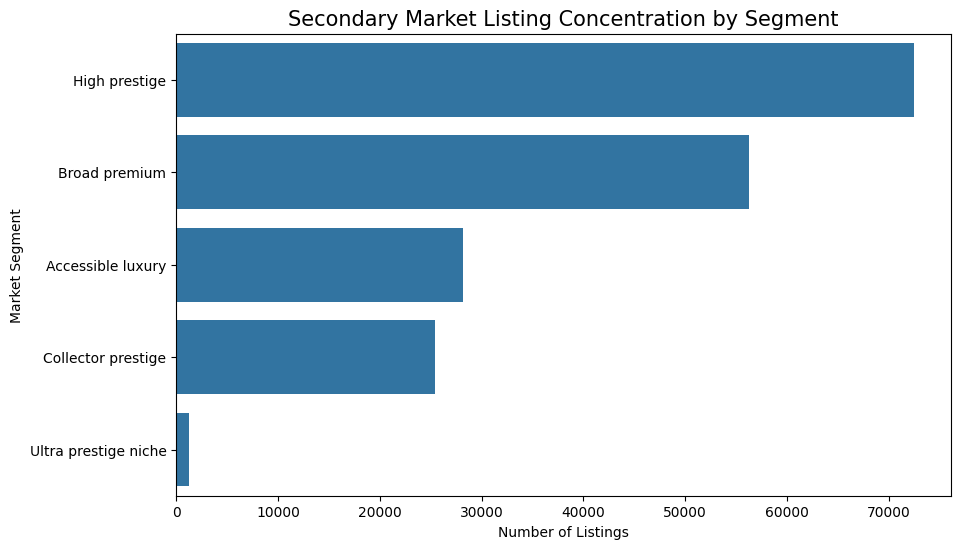

In [28]:
segment_counts = (
    market_focus_df["market_segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = [
    "market_segment",
    "listing_count"
]

plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_counts,
    x="listing_count",
    y="market_segment"
)

plt.title(
    "Secondary Market Listing Concentration by Segment",
    fontsize=15
)

plt.xlabel("Number of Listings")
plt.ylabel("Market Segment")

plt.show()

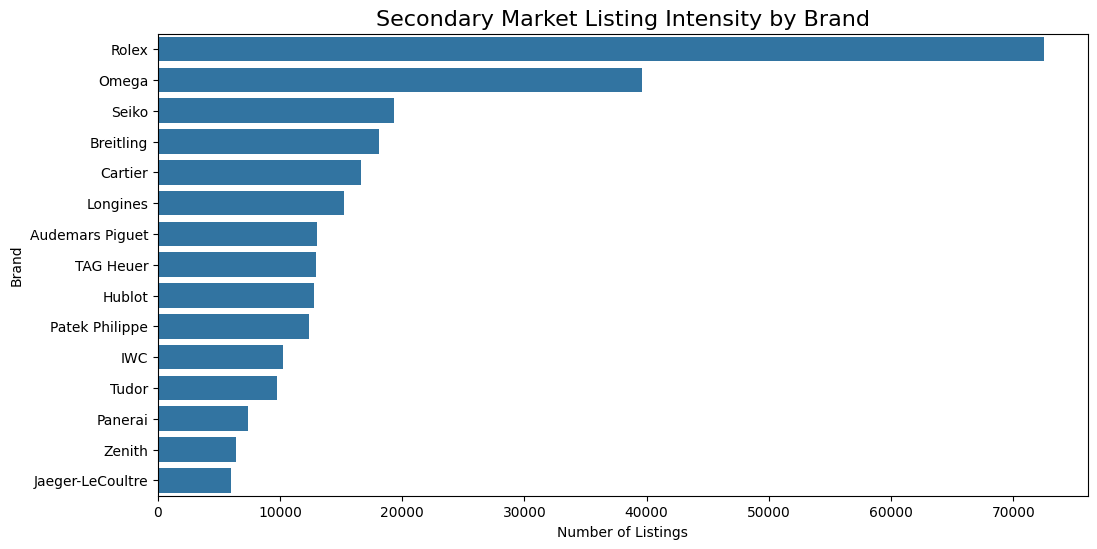

In [ ]:
# Listing Intensity by Brand --- Rolex secondary market liquidity dominance
listing_brand = (
    market_df["brand"]
    .value_counts()
    .reset_index()
)

listing_brand.columns = [
    "brand",
    "listing_count"
]

plt.figure(figsize=(12,6))

sns.barplot(
    data=listing_brand.head(15),
    x="listing_count",
    y="brand"
)

plt.title(
    "Secondary Market Listing Intensity by Brand",
    fontsize=16
)

plt.xlabel("Number of Listings")
plt.ylabel("Brand")

plt.show()

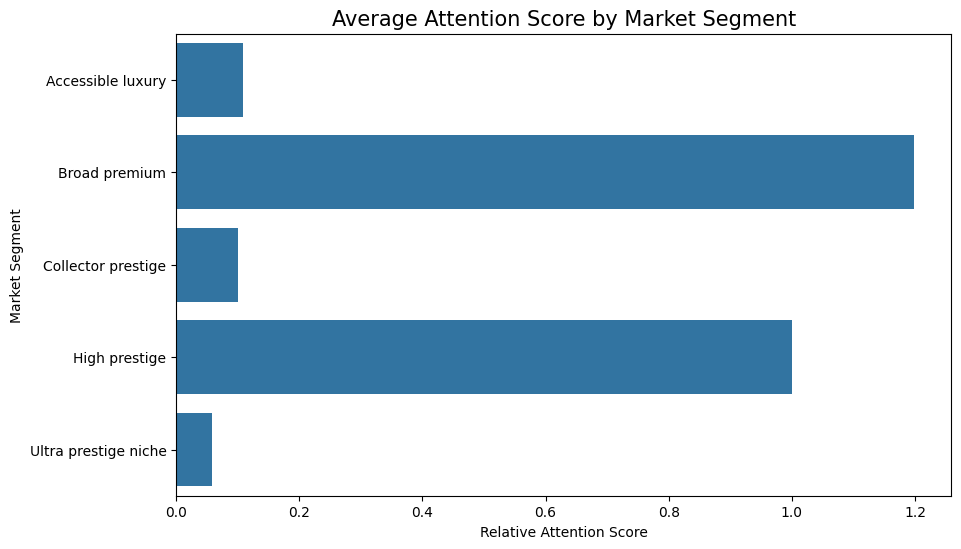

In [31]:
#Segment vs Attention
segment_attention = (
    market_focus_df
    .groupby("market_segment")[
        "relative_attention_score"
    ]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_attention,
    x="relative_attention_score",
    y="market_segment"
)

plt.title(
    "Average Attention Score by Market Segment",
    fontsize=15
)

plt.xlabel("Relative Attention Score")
plt.ylabel("Market Segment")

plt.show()

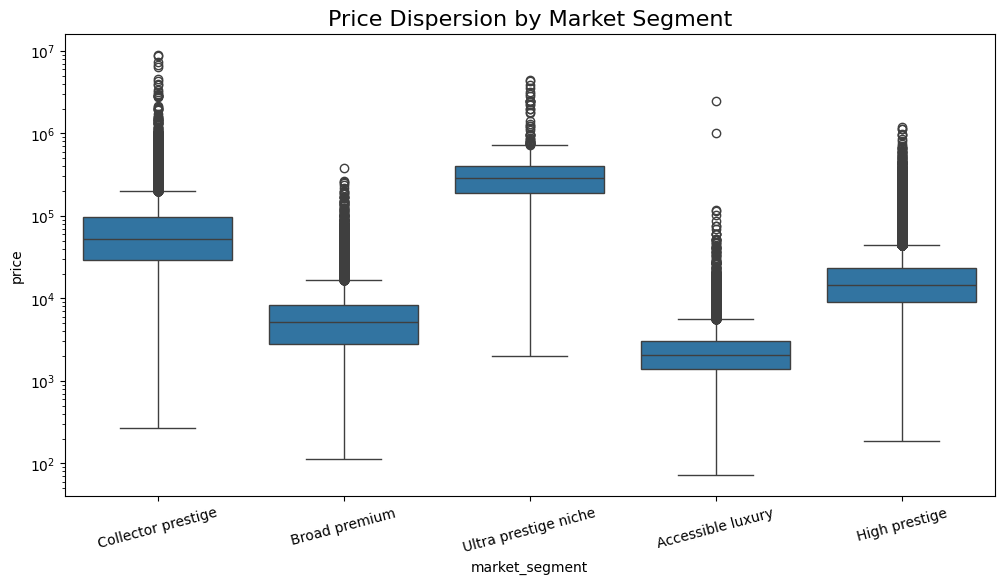

In [32]:
#Price Dispersion by Segment

plt.figure(figsize=(12,6))

sns.boxplot(
    data=market_df,
    x="market_segment",
    y="price"
)

plt.yscale("log")

plt.xticks(rotation=15)

plt.title(
    "Price Dispersion by Market Segment",
    fontsize=16
)

plt.show()

In [35]:
brand_metrics = (
    market_focus_df
    .groupby(["brand", "market_segment"])
    .agg(
        avg_price=("price", "mean"),
        relative_attention_score=("relative_attention_score", "mean"),
        listing_count=("brand", "count")
    )
    .reset_index()
)

brand_metrics

,brand,market_segment,avg_price,relative_attention_score,listing_count
0,Audemars Piguet,Collector prestige,73932.483066,0.085438,12987
1,Cartier,Broad premium,8919.843106,0.629540,16607
2,Longines,Accessible luxury,2347.270951,0.104848,15221
3,Omega,Broad premium,6390.521036,1.437219,39631
4,Patek Philippe,Collector prestige,102007.831940,0.115531,12397
5,Richard Mille,Ultra prestige niche,370190.514667,0.058995,1242
6,Rolex,High prestige,21854.864022,1.000000,72484
7,TAG Heuer,Accessible luxury,3205.537030,0.113026,12908


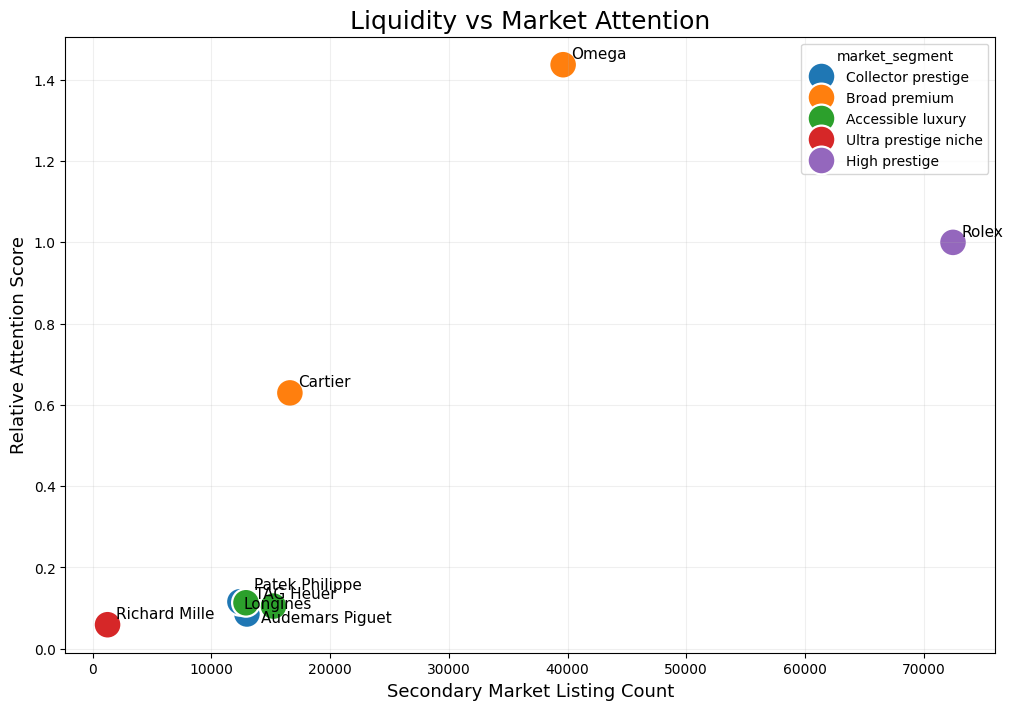

In [43]:

# Strategic positioning map: liquidity vs attention

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=brand_metrics,
    x="listing_count",
    y="relative_attention_score",
    hue="market_segment",
    s=400
)

for _, row in brand_metrics.iterrows():

    x_offset = 700
    y_offset = 0.015

    # custom offsets
    if row["brand"] == "Patek Philippe":
        x_offset = 1200
        y_offset = 0.03

    elif row["brand"] == "Audemars Piguet":
        x_offset = 1200
        y_offset = -0.02

    elif row["brand"] == "Longines":
        x_offset = -2500
        y_offset = -0.005

    elif row["brand"] == "TAG Heuer":
        x_offset = 800
        y_offset = 0.01

    plt.text(
        row["listing_count"] + x_offset,
        row["relative_attention_score"] + y_offset,
        row["brand"],
        fontsize=11
    )

plt.title("Liquidity vs Market Attention", fontsize=18)
plt.xlabel("Secondary Market Listing Count", fontsize=13)
plt.ylabel("Relative Attention Score", fontsize=13)

plt.grid(alpha=0.2)
plt.show()

Rolex dominates liquidity + sustained attention
Omega overperforms in public attention relative to market liquidity
Collector prestige brands generate high value but limited mainstream attention
Ultra prestige niche operates outside mass attention dynamics